# Quantum teleportation and superdense coding

## Quantum teleportation

We are going to use Qiskit to implement the quantum teleportation protocol

In [ ]:
%matplotlib inline

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
import random


# We will create a random qubit by directly assigning random amplitudes

a1 = random.uniform(-1, 1)  # Uniform number in [-1, 1]
a2 = random.uniform(-1, 1)
b1 = random.uniform(-1, 1)
b2 = random.uniform(-1, 1)

# We need to normalize the amplitudes

norm = (a1**2 + a2**2 + b1**2 + b2**2) ** 0.5

c1 = complex(a1 / norm, a2 / norm)  # Amplitude for |0>
c2 = complex(b1 / norm, b2 / norm)  # Amplitude for |1>

# Create quantum and classical registers

psi = QuantumRegister(1, name="psi")       # The qubit to teleport
bell = QuantumRegister(2, name="bell")     # The shared entangled pair
c = ClassicalRegister(2, name="c")         # Two classical bits for measurement

# Create the quantum circuit

teleport = QuantumCircuit(psi, bell, c)

# Initialize Alice's qubit to |ψ> = c1|0> + c2|1>

teleport.initialize([c1, c2], psi[0])

teleport.barrier()

print("Alice's qubit is:")
print(c1, "|0> +", c2, "|1>")

In [ ]:
# Now we create the Bell pair

teleport.h(bell[0])
teleport.cx(bell[0],bell[1])
teleport.barrier()

# We apply CNOT to |psi> and Alice's part of the entangled pair
# We also apply the H gate
# Then, Alice measure her qubits and send the results to Bob

teleport.cx(psi,bell[0])
teleport.h(psi)
#teleport.measure([psi[0],bell[0]],c)
teleport.barrier()

# Bob applies his gates depending on the values received from Alice 

teleport.cx(bell[0],bell[1])
teleport.cz(psi,bell[1])

teleport.draw(output='mpl');

from qiskit.primitives import StatevectorSampler
sampler = StatevectorSampler()

teleport.measure_all()
job = sampler.run(
        [teleport],   # [qc_send] one circuit, one job per qubit
        shots=1000
    )
results = job.result()
count = results[0].data.meas.get_counts()
print(count)


In [ ]:
# We run the circuit and access the amplitudes to check that Bob got the qubit

from qiskit.quantum_info import Statevector

teleportedstate = Statevector.from_instruction(teleport)

print(teleportedstate)

# Supendense coding

 ### superdense coding is a quantum communication protocol to communicate a number of classical bits (here are two bits) of information by only transmitting a smaller number of qubits (one qubit), under the assumption of sender and receiver pre-sharing an entangled resource.

1. The protocol starts with the preparation of an entangled state, which is later shared between Alice and Bob.

2. By applying a quantum gate to her qubit locally, Alice can transform the entangled state, into any of the four Bell states. Note that this process cannot "break" the entanglement between the two qubits.

3. In order for Bob to find out which classical bits Alice sent he will perform the CNOT unitary operation, with A as control qubit and B as target qubit. Then, he will perform H⊗I unitary operation on the entangled qubit A (H is only applied to A).

Now, we are going to implement a circuit to simulate superdense coding


Alice wants to send  1 0


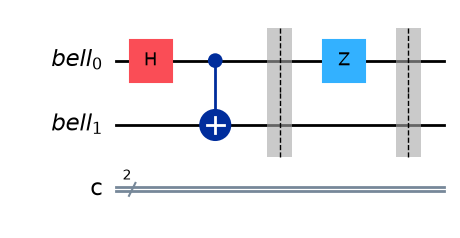

In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
import random

# We start by creating the Bell pair that Alice and Bob share

bell = QuantumRegister(2, name = 'bell') # We need two qubits
c = ClassicalRegister(2, name = 'c') # And two bits for the measurements 
dense = QuantumCircuit(bell,c)
dense.h(bell[0])
dense.cx(bell[0],bell[1])
dense.barrier()

# We randomly choose which bits to send

b1 = random.randint(0,1)
b2 = random.randint(0,1)

print("Alice wants to send ",b1,b2)

# And we apply the gates accordingly

if(b2==1):
    dense.x(bell[0])
if(b1==1):
    dense.z(bell[0])
    
dense.barrier()

dense.draw(output='mpl')

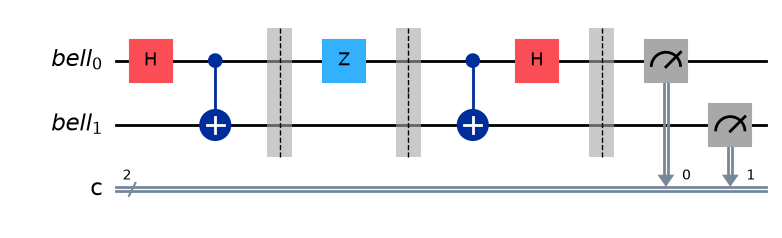

In [2]:
# Alice sends her qubit to Bob, who applies his gates and measures

dense.cx(bell[0],bell[1])
dense.h(bell[0])
dense.barrier()
dense.measure(bell,c)
dense.draw(output='mpl')

In [3]:
# Let run the circuit

from qiskit.primitives import StatevectorSampler

sampler = StatevectorSampler()

job = sampler.run([dense], shots=1)

result = job.result()

counts = result[0].data.c.get_counts()

print("Bob has received ", list(counts.keys())[0][1], list(counts.keys())[0][0])

Bob has received  1 0
